## Health Insurance Claims
Health Insurance Underwriting with Simulated Health Insurance Dataset

### 1. Setup & Libraries

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [43]:
# Disable warnings in jupyter notebook
# Source - https://stackoverflow.com/a/52294671
# Posted by Ramon Crehuet
# Retrieved 2026-06-02, License - CC BY-SA 4.0

import warnings
warnings.filterwarnings('ignore')


### 2. Simulated Health Insurance Dataset

In [44]:
my_seed = 42
np.random.seed(my_seed)

# Generate 5000 datapoints
n = 5000
df = pd.DataFrame({
    "age": np.random.randint(18, 80, n),
    "bmi": np.random.normal(27, 5, n).round(1),
    "smoker": np.random.choice([0,1], n, p=[0.8, 0.2]),
    "chronic_conditions": np.random.poisson(0.6, n),
    "gender": np.random.choice(["M","F"], n),
    "region": np.random.choice(["North","South","East","West"], n),
})

# Claims cost model (synthetic)
df["claims_cost"] = (
    df["age"]*12 +
    df["bmi"]*15 +
    df["smoker"]*2000 +
    df["chronic_conditions"]*800 +
    np.random.normal(0, 500, n)
).clip(lower=0)

df.head()

,age,bmi,smoker,chronic_conditions,gender,region,claims_cost
0,56,11.9,0,0,M,East,802.010000
1,69,27.9,1,0,F,East,3223.745663
2,46,36.0,0,1,M,East,1520.168451
3,32,33.2,0,0,F,North,1022.834285
4,60,28.0,0,0,F,West,1348.900169


In [58]:
df.shape

(5000, 13)

### Exploratory Data Analysis

In [45]:
# Set the plotting style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("--- Data Snapshot ---")
print(df.head(), "\n")

--- Data Snapshot ---
   age   bmi  smoker  chronic_conditions gender region  claims_cost
0   56  11.9       0                   0      M   East   802.010000
1   69  27.9       1                   0      F   East  3223.745663
2   46  36.0       0                   1      M   East  1520.168451
3   32  33.2       0                   0      F  North  1022.834285
4   60  28.0       0                   0      F   West  1348.900169 



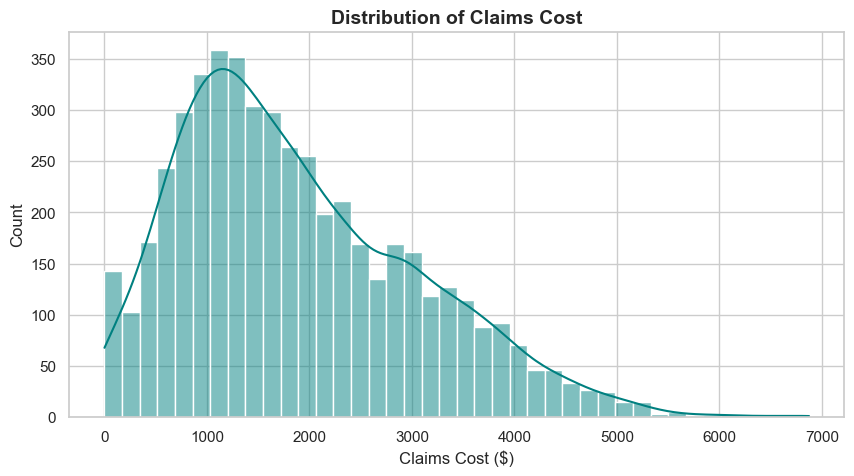

In [46]:
# Plot 1: Distribution of the Target Variable (claims_cost)
plt.figure(figsize=(10, 5))
sns.histplot(df['claims_cost'], kde=True, color='teal', bins=40)
plt.title('Distribution of Claims Cost', fontsize=14, fontweight='bold')
plt.xlabel('Claims Cost ($)')
plt.ylabel('Count')
plt.savefig("images/Distribution_of_Claims_Cost.png")  # Save Distribution of Claims Cost
plt.show()

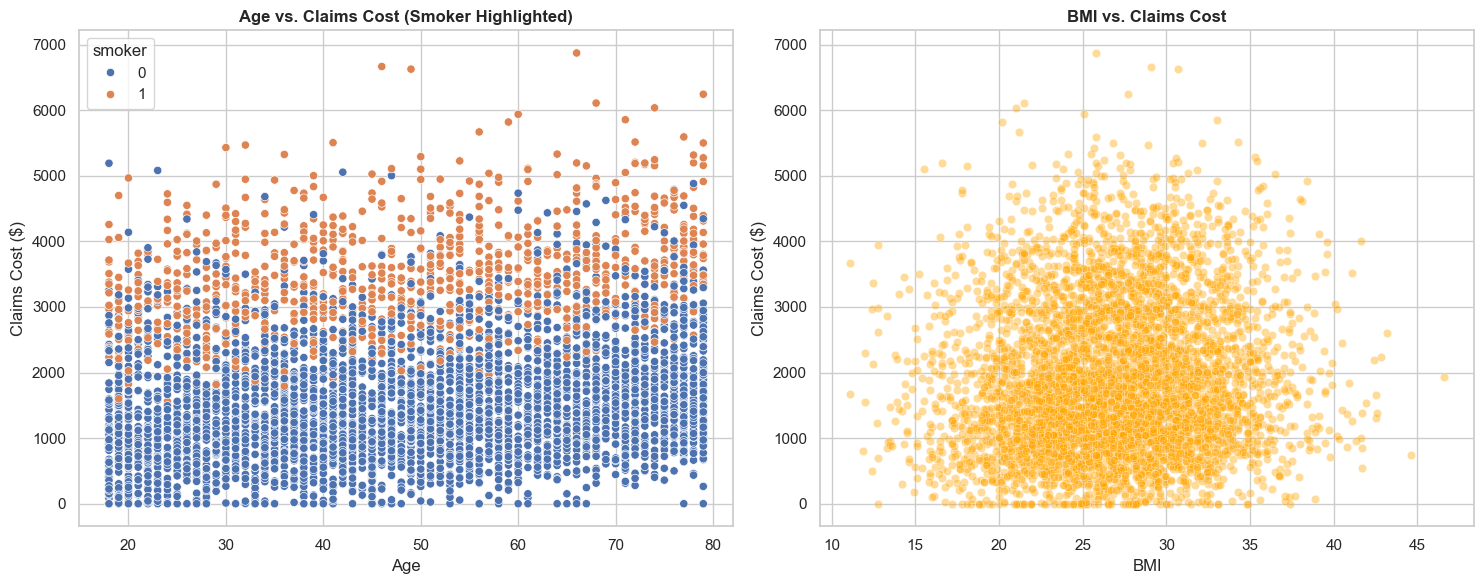

In [47]:
# Plot 2: Age & BMI vs. Claims Cost (Numerical Relationships)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# sns.scatterplot(data=df, x='age', y='claims_cost', alpha=0.4, ax=axes[0], color='blue')
sns.scatterplot(data=df, x='age', y='claims_cost', hue="smoker", ax=axes[0], color='blue')
axes[0].set_title('Age vs. Claims Cost (Smoker Highlighted)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Claims Cost ($)')

sns.scatterplot(data=df, x='bmi', y='claims_cost', alpha=0.4, ax=axes[1], color='orange')
axes[1].set_title('BMI vs. Claims Cost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Claims Cost ($)')

plt.tight_layout()
plt.savefig("images/Age_&_BMI_vs_Claims_Cost.png")  # Save Age & BMI vs. Claims Cost
plt.show()

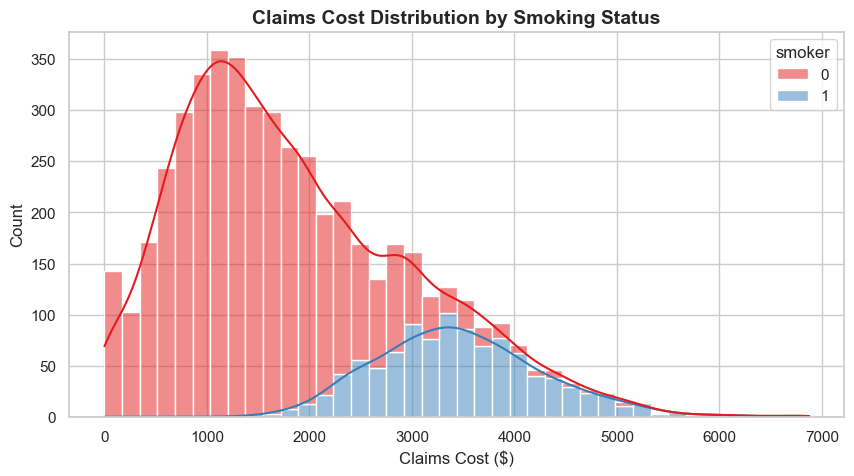

In [48]:
# Plot 3: Impact of Smoking Status (The clear bimodal split in the data)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='claims_cost', hue='smoker', kde=True, bins=40, palette='Set1', multiple='stack')
plt.title('Claims Cost Distribution by Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Claims Cost ($)')
plt.savefig("images/Claims_Cost_Distribution_by_Smoking_Status.png")  # Save Claims Cost Distribution by Smoking Status
plt.show()

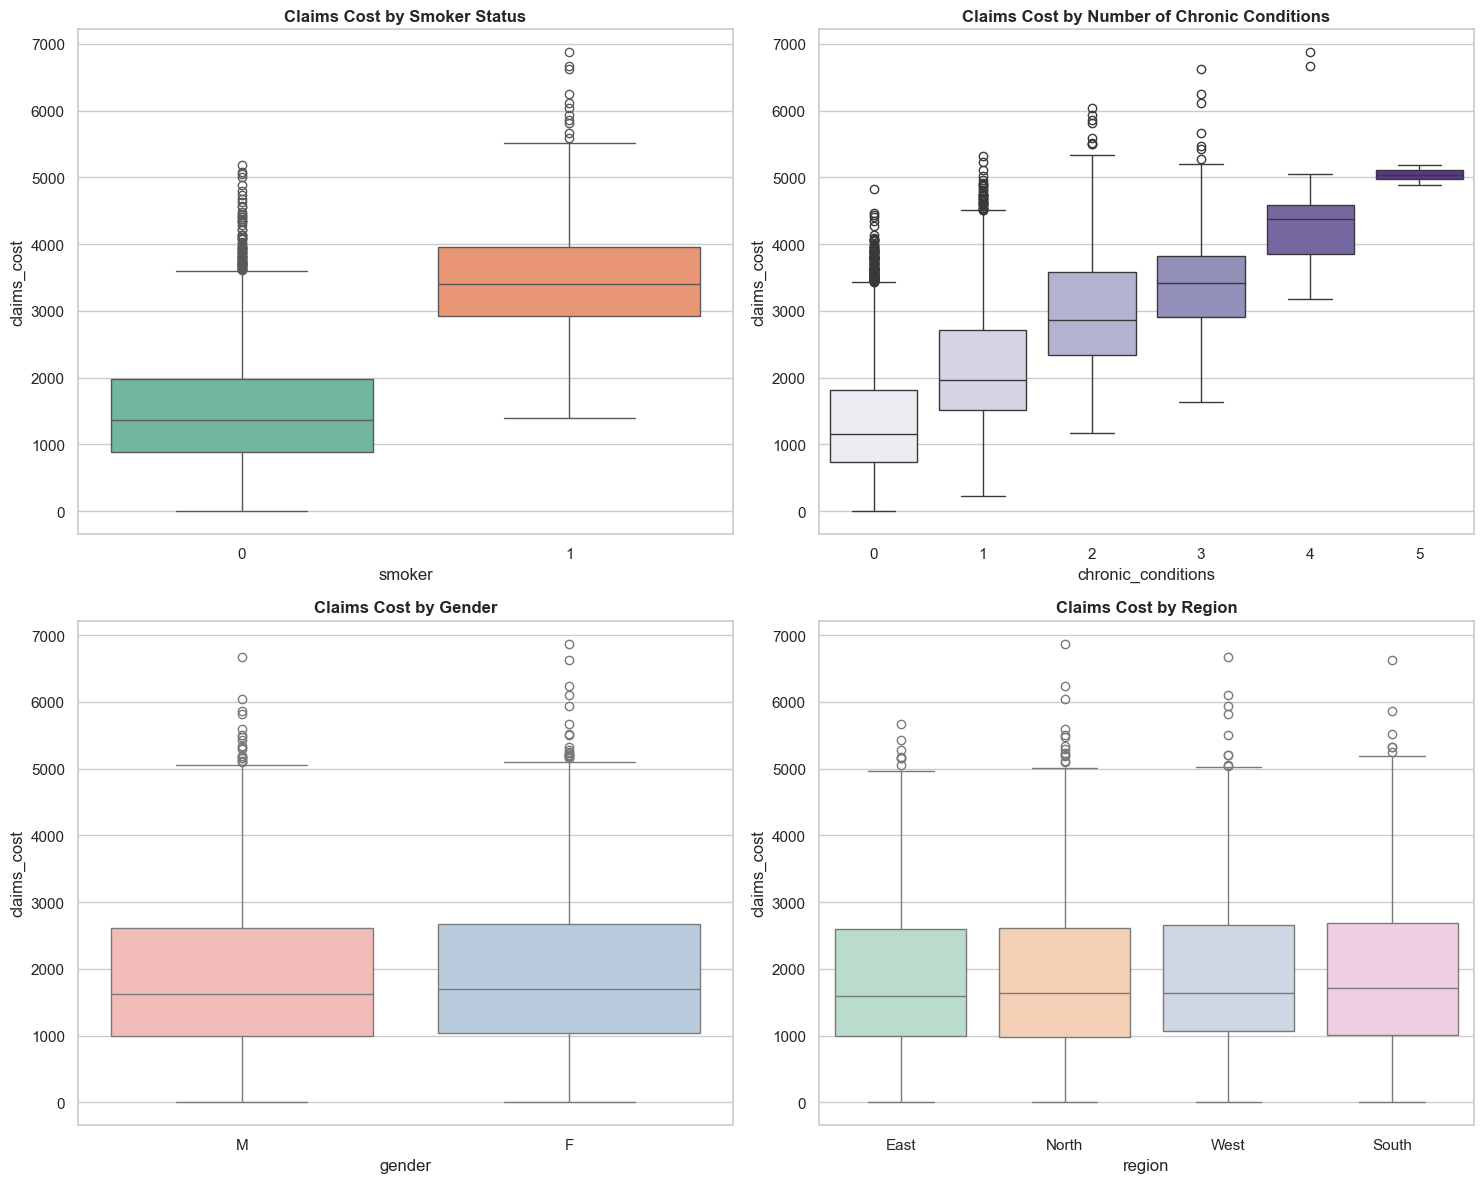

In [49]:
# Plot 4: Categorical Features Analysis (Smoker, Chronic Conditions, Gender, Region)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.boxplot(data=df, x='smoker', y='claims_cost', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Claims Cost by Smoker Status', fontweight='bold')

sns.boxplot(data=df, x='chronic_conditions', y='claims_cost', ax=axes[0,1], palette='Purples')
axes[0,1].set_title('Claims Cost by Number of Chronic Conditions', fontweight='bold')

sns.boxplot(data=df, x='gender', y='claims_cost', ax=axes[1,0], palette='Pastel1')
axes[1,0].set_title('Claims Cost by Gender', fontweight='bold')

sns.boxplot(data=df, x='region', y='claims_cost', ax=axes[1,1], palette='Pastel2')
axes[1,1].set_title('Claims Cost by Region', fontweight='bold')

plt.tight_layout()
plt.savefig("images/Categorical_Features_Analysis.png")  # Save Categorical Features Analysis
plt.show()

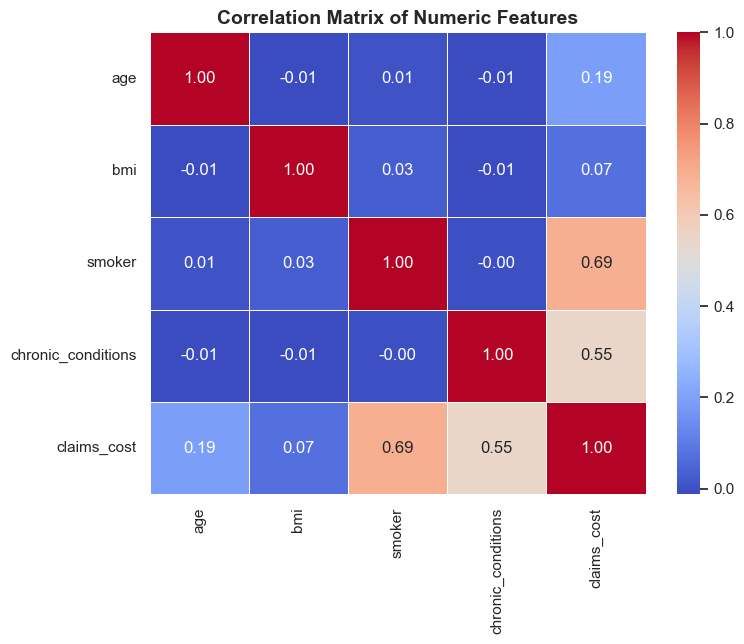

In [50]:
# Plot 5: Correlation Heatmap (To verify linear weights)
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation calculation
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.savefig("images/Correlation_Heatmap.png")  # Save Correlation Heatmap
plt.show()

### Risk Segmentation

In [51]:
df["risk_score"] = (
    df["age"]*0.02 +
    df["bmi"]*0.03 +
    df["smoker"]*1.5 +
    df["chronic_conditions"]*0.8
)

df["risk_band"] = pd.qcut(df["risk_score"], q=4, labels=["Low","Medium","High","Very High"])

df["risk_band"].value_counts()

risk_band
Low          1252
High         1252
Medium       1248
Very High    1248
Name: count, dtype: int64

###  Claims Cost Prediction Model - Using Random Forest

In [52]:
X = df[["age","bmi","smoker","chronic_conditions"]]
y = df["claims_cost"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

MAE: 444.18856128170694
R²: 0.7640341837343088


### Pricing Adequacy Check

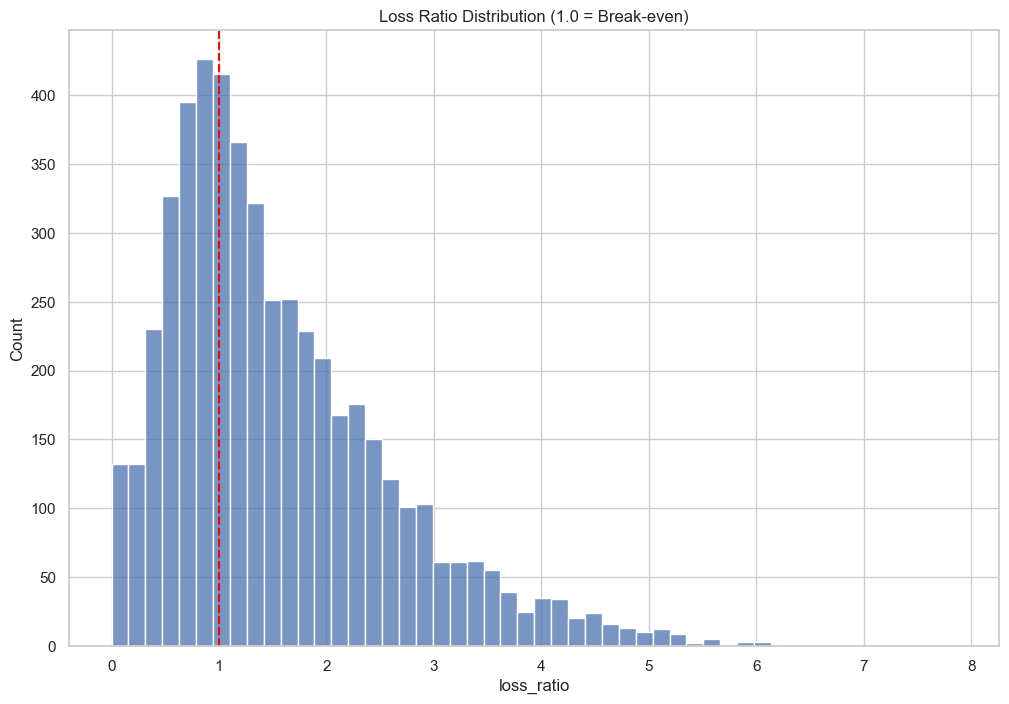

In [53]:
# Assume current premium is based on simple age-based pricing

df["current_premium"] = df["age"] * 20 + 300

df["loss_ratio"] = df["claims_cost"] / df["current_premium"]

sns.histplot(df["loss_ratio"], bins=50)
plt.axvline(1.0, color="red", linestyle="--")
plt.title("Loss Ratio Distribution (1.0 = Break-even)")
plt.savefig("images/Loss_Ratio_Distribution.png")  # Save Loss Ratio Distribution
plt.show()

In [54]:
df.groupby("risk_band")["loss_ratio"].mean()

risk_band
Low          0.842908
Medium       1.082202
High         1.715152
Very High    2.596378
Name: loss_ratio, dtype: float64

### Scenario Testing: New Pricing Strategy

In [55]:
df["proposed_premium"] = (
    300 +
    df["risk_score"]*150 +
    df["chronic_conditions"]*50
)

df["new_loss_ratio"] = df["claims_cost"] / df["proposed_premium"]

df[["loss_ratio","new_loss_ratio"]].describe()

,loss_ratio,new_loss_ratio
count,5000.000000,5000.000000
mean,1.558712,2.460007
std,1.053829,1.097865
min,0.000000,0.000000
25%,0.796094,1.679074
50%,1.299557,2.448717
75%,2.104709,3.262189
max,7.867005,5.595243


### Impact Summary

In [56]:
summary = df.groupby("risk_band")[["claims_cost","current_premium","proposed_premium","loss_ratio","new_loss_ratio"]].mean()
summary

,claims_cost,current_premium,proposed_premium,loss_ratio,new_loss_ratio
risk_band,,,,,
Low,837.079331,1021.150160,526.706789,0.842908,1.580512
Medium,1299.348193,1352.179487,630.842027,1.082202,2.051667
High,2020.043036,1325.894569,756.622085,1.715152,2.666605
Very High,3386.388339,1405.881410,953.842268,2.596378,3.543403


In [57]:
# Save generated dataset
df.to_csv("health-insurance-output.csv", index=False)